# AutoEIT — Volleyball Sentence Analysis
Locates the EIT item "We're going to play volleyball at the gym that I told you about."
in every recording's transcription. Whisper transcripts vary a lot from the canonical stimulus
(contractions, dropped/added words, garbled ASR output), so matching is done by checking for the
presence of both "volleyball" and "gym" in an item's text rather than an exact string match.

If the sentence is matched in more than one item within a recording, the **last** matching item
(highest item index) is used for the index-distribution plot, and the recording is also tracked
separately as a "double occurrence" case. version_a and version_b are processed independently
throughout.

In [1]:
import json
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

## Config

In [2]:
TRANSCRIBED_ROOT = Path("../../data/transcribed/v1")
VERSIONS = ["version_a", "version_b"]

# An item's text counts as a match if it contains both keywords (case-insensitive).
# The canonical stimulus is "We're going to play volleyball at the gym that I told you about.",
# but ASR transcripts of it vary widely (contractions, dropped/added words, garbled endings),
# so an exact string match would miss almost every real occurrence.
MATCH_KEYWORDS = ["volleyball", "gym"]

# Same thresholds as analyze_anomalies.ipynb
LOW_THRESHOLD = 30   # item_count < LOW_THRESHOLD -> short anomaly
HIGH_THRESHOLD = 40  # item_count > HIGH_THRESHOLD -> long anomaly


def matches_sentence(text: str) -> bool:
    t = text.lower()
    return all(kw in t for kw in MATCH_KEYWORDS)


def categorize(item_count: int) -> str:
    if item_count > HIGH_THRESHOLD:
        return "long anomaly"
    if item_count < LOW_THRESHOLD:
        return "short anomaly"
    return "good"


## Scan transcriptions for the target sentence
For each recording, find every item whose text matches, keep the last matching item for the
index-distribution plot, and flag recordings where the sentence occurs more than once.

In [3]:
def scan_version(version: str) -> pd.DataFrame:
    version_dir = TRANSCRIBED_ROOT / version
    rows = []
    for summary_path in sorted(version_dir.glob("*/summary.json")):
        with open(summary_path) as f:
            s = json.load(f)
        matched_items = [it for it in s["items"] if matches_sentence(it["text"])]
        if not matched_items:
            rows.append({
                "recording": s["recording"],
                "version": s["version"],
                "item_count": s["item_count"],
                "found": False,
                "match_count": 0,
                "matched_indices": [],
                "last_index": None,
            })
            continue
        matched_items = sorted(matched_items, key=lambda it: it["index"])
        rows.append({
            "recording": s["recording"],
            "version": s["version"],
            "item_count": s["item_count"],
            "found": True,
            "match_count": len(matched_items),
            "matched_indices": [it["index"] for it in matched_items],
            "last_index": matched_items[-1]["index"],
        })
    return pd.DataFrame(rows)


results = {version: scan_version(version) for version in VERSIONS}

## Persist results back into each recording's summary.json
For every recording, add:
- `last_english_item`: list of item indices where the sentence was matched (empty if not found,
  more than one entry if the sentence occurred more than once).
- `category`: `"short anomaly"` / `"good"` / `"long anomaly"`, based on `item_count`, using the same
  thresholds as `analyze_anomalies.ipynb`.

In [4]:
for version in VERSIONS:
    df = results[version]
    version_dir = TRANSCRIBED_ROOT / version
    for _, row in df.iterrows():
        summary_path = version_dir / row["recording"] / "summary.json"
        with open(summary_path, encoding="utf-8") as f:
            s = json.load(f)
        s.pop("target_sentence_indices", None)
        s["last_english_item"] = row["matched_indices"]
        s["category"] = categorize(row["item_count"])
        with open(summary_path, "w", encoding="utf-8") as f:
            json.dump(s, f, ensure_ascii=False, indent=2)
    print(f"{version}: updated {len(df)} summary.json file(s)")

version_a: updated 102 summary.json file(s)


version_b: updated 103 summary.json file(s)


## Statistics — how many recordings contained the sentence

In [5]:
for version in VERSIONS:
    df = results[version]
    n_total = len(df)
    n_found = int(df["found"].sum())
    n_double = int((df["match_count"] > 1).sum())
    print(f"=== {version} ===")
    print(f"  recordings scanned:        {n_total}")
    print(f"  sentence found in:         {n_found}  ({n_found / n_total:.1%})")
    print(f"  not found in:              {n_total - n_found}")
    print(f"  found more than once in:   {n_double}")
    print()

=== version_a ===
  recordings scanned:        102
  sentence found in:         97  (95.1%)
  not found in:              5
  found more than once in:   16

=== version_b ===
  recordings scanned:        103
  sentence found in:         101  (98.1%)
  not found in:              2
  found more than once in:   20



## Recordings where the sentence was not found
Listed for reference — these are likely anomalous recordings (missing or heavily garbled items).

In [6]:
for version in VERSIONS:
    df = results[version]
    missing = df[~df["found"]][["recording", "item_count"]].reset_index(drop=True)
    print(f"=== {version}: {len(missing)} recording(s) without the sentence ===")
    display(missing)

=== version_a: 5 recording(s) without the sentence ===


,recording,item_count
0,038.100_EIT-v1A,38
1,038021_EIT-1A,32
2,038026_EIT-2A,37
3,038066_EITv-1A,1
4,038test_EITvA1,2


=== version_b: 2 recording(s) without the sentence ===


,recording,item_count
0,038039_EITv-2B,1
1,038065_EITv-1B,10


## Distribution of item index where the sentence occurred
Uses the last matching item per recording when the sentence appears more than once.

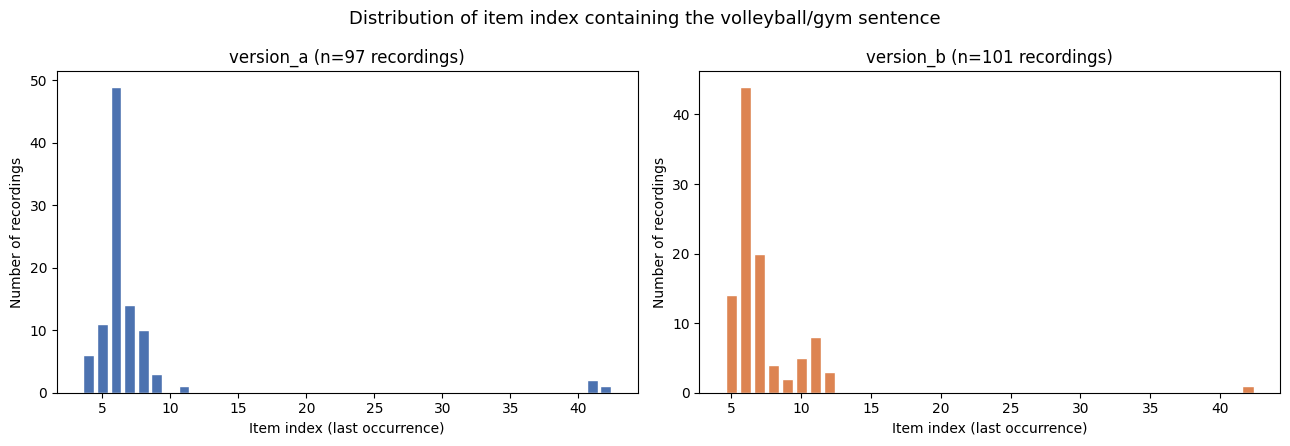

In [7]:
colors = {"version_a": "#4C72B0", "version_b": "#DD8452"}

fig, axes = plt.subplots(1, len(VERSIONS), figsize=(13, 4.5), sharey=False)

for ax, version in zip(axes, VERSIONS):
    df = results[version]
    found = df[df["found"]]
    counts = found["last_index"].value_counts().sort_index()
    ax.bar(counts.index, counts.values, color=colors[version], edgecolor="white")
    ax.set_title(f"{version} (n={len(found)} recordings)", fontsize=12)
    ax.set_xlabel("Item index (last occurrence)")
    ax.set_ylabel("Number of recordings")

fig.suptitle("Distribution of item index containing the volleyball/gym sentence", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/volleyball_sentence_index_distribution.png", dpi=150)
plt.show()

## Recordings where the sentence occurred twice
For these, check whether the recording falls into the "long anomaly" (> 40 items) or "good"
(30–40 items) category, using the same thresholds as `analyze_anomalies.ipynb`.

In [8]:
for version in VERSIONS:
    df = results[version]
    doubles = df[df["match_count"] > 1].copy()
    doubles["category"] = doubles["item_count"].apply(categorize)
    print(f"=== {version}: {len(doubles)} recording(s) with the sentence twice ===")
    display(
        doubles[["recording", "item_count", "matched_indices", "category"]]
        .sort_values("item_count", ascending=False)
        .reset_index(drop=True)
    )

=== version_a: 16 recording(s) with the sentence twice ===


,recording,item_count,matched_indices,category
0,038016_EIT-2A,72,"[5, 41]",long anomaly
1,038008_EIT-2A,72,"[5, 42]",long anomaly
2,038012_EIT-2A,72,"[5, 41]",long anomaly
3,038.093_EIT2_vA,63,"[8, 9]",long anomaly
4,038.085_EIT2_vA,61,"[7, 8]",long anomaly
5,038.103_EIT2_vA,60,"[6, 7]",long anomaly
6,038.095_EIT2_vA,60,"[7, 8]",long anomaly
7,038.087_EIT2_vA,60,"[7, 8]",long anomaly
8,038.099_EIT2_vA,60,"[7, 8]",long anomaly
9,038.082_EIT1_vA,59,"[7, 8]",long anomaly


=== version_b: 20 recording(s) with the sentence twice ===


,recording,item_count,matched_indices,category
0,038019_EIT-2B,75,"[7, 42]",long anomaly
1,038.099_EIT1_vB,73,"[10, 11]",long anomaly
2,038.084_EIT2_vB,71,"[10, 11]",long anomaly
3,038.107_EIT1_vB,69,"[11, 12]",long anomaly
4,038.090_EIT2_vB,68,"[11, 12]",long anomaly
5,038.097_EIT1_vB,67,"[10, 11]",long anomaly
6,038.098_EIT2_vB,67,"[9, 10]",long anomaly
7,038.103_EIT1_vB,67,"[10, 11]",long anomaly
8,038.087_EIT1_vB (1),66,"[7, 8]",long anomaly
9,038.093_EIT1_vB,66,"[9, 10]",long anomaly


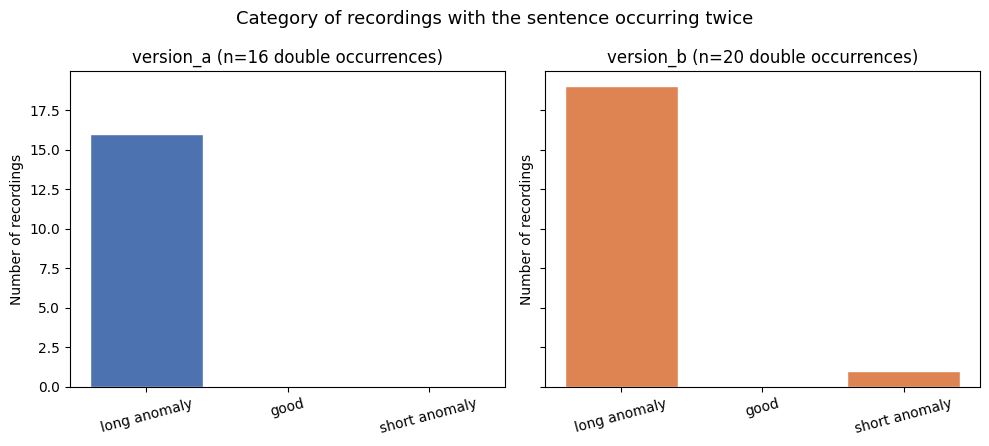

In [9]:
category_order = ["long anomaly", "good", "short anomaly"]

fig, axes = plt.subplots(1, len(VERSIONS), figsize=(10, 4.5), sharey=True)

for ax, version in zip(axes, VERSIONS):
    df = results[version]
    doubles = df[df["match_count"] > 1].copy()
    doubles["category"] = doubles["item_count"].apply(categorize)
    counts = doubles["category"].value_counts().reindex(category_order, fill_value=0)
    ax.bar(counts.index, counts.values, color=colors[version], edgecolor="white")
    ax.set_title(f"{version} (n={len(doubles)} double occurrences)", fontsize=12)
    ax.set_ylabel("Number of recordings")
    ax.tick_params(axis="x", rotation=15)

fig.suptitle("Category of recordings with the sentence occurring twice", fontsize=13)
fig.tight_layout()
plt.savefig("../plots/volleyball_sentence_double_occurrence_category.png", dpi=150)
plt.show()

## Save double-occurrence recording names
Writes the recording names (one per line, no other columns) to a dedicated file per version in
`../../data/`, for reuse in future tasks.

In [10]:
DOUBLE_OCCURRENCE_ROOT = Path("../../data")

for version in VERSIONS:
    df = results[version]
    doubles = df[df["match_count"] > 1].sort_values("recording")
    out_path = DOUBLE_OCCURRENCE_ROOT / f"double_occurrence_recordings_{version}.txt"
    out_path.write_text("\n".join(doubles["recording"]) + "\n")
    print(f"{version}: wrote {len(doubles)} recording name(s) to {out_path}")

version_a: wrote 16 recording name(s) to ../data/double_occurrence_recordings_version_a.txt
version_b: wrote 20 recording name(s) to ../data/double_occurrence_recordings_version_b.txt
